## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Select filepath

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# change current directory to parent folder
if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth/") + "/"

save_figs = False
overall_name = 'NetZero_0-10-100TWhExp'

## Import networks

In [3]:
# n_0 = pypsa.Network("KENYA-1h.nc")
# n_50 = pypsa.Network("KENYA-50h.nc")
# n_100 = pypsa.Network("KENYA-100h.nc")
# n_200 = pypsa.Network("KENYA-200h.nc")

regions_onshore_path = PARENT + "resources/KENYA/shapes/country_shapes.geojson"
gadm_shapes_path = PARENT + "resources/KENYA/shapes/gadm_shapes.geojson"

warnings.simplefilter(action='ignore', category=FutureWarning)
# # n = pypsa.Network(results_path)
# n = pypsa.Network('pypsa-earth/results/EG-sec-WS/postnetworks/elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_107export.nc')
regions_onshore = gpd.read_file(regions_onshore_path)
# bus_regions = gpd.read_file(bus_regions)
# # New
gadm_shapes = gpd.read_file(gadm_shapes_path)
gadm_shapes = gadm_shapes.set_index('GADM_ID')
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


## Plot multiple

In [4]:
# Assuming your .nc files live in elec_dir
elec_dir = "pypsa-earth/results/KENYA/postnetworks/"

# Collect all the .nc files
nc_files = [
    "elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_0export.nc",
    "elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_50export.nc",
    "elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_100export.nc",
    "elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_200export.nc"
]

# Prepare dicts
networks = {}
#regions_onshore = {}
gadm_regions = {}

# Loop and load
for f in nc_files:
    # Derive keys from filename
    base = os.path.splitext(f)[0]  # strip ".nc"
    parts = base.split("_")
    
    # Example: ["elec","s","8","ec","lcopt","Co2L0-3H","24H","2050","0.071","NZ","0export"]
    co2_policy = parts[5]   # e.g. "Co2L0.3-3H"
    export_policy = parts[-1]  # e.g. "0export" or "107export"
    
    key = co2_policy
    h2export_key = export_policy

    # Init dicts if not already
    if key not in networks:
        networks[key] = {}
        #regions_onshore[key] = {}
        #gadm_regions[key] = {}
    
    # Load PyPSA network
    path = os.path.join(elec_dir, f)
    networks[key][h2export_key] = pypsa.Network(path)
    
    #regions_onshore[key][h2export_key] = gpd.read_file(s["regions_onshore_path"])
    #gadm_regions[key][h2export_key] = gpd.read_file(s["gadm_path"])


Index(['H2 pipeline KE.10_1_AC -> KE.25_1_DC'], dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline KE.10_1_AC -> KE.25_1_DC'], dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_50export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline KE.10_1_AC -> KE.25_1_DC'], dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_100export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline KE.10_1_AC -> KE.25_1_DC'], dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_2_ec_lcopt_Co2L0.00-3H_3H_2050_0.071_NZ_200export.nc has buses, carriers, generators, global_con

In [11]:
networks['Co2L0.00-3H']['100export'].export_to_netcdf('Kenya-Export-Network.nc')

INFO:pypsa.io:Exported network 'Kenya-Export-Network.nc' contains: storage_units, buses, lines, carriers, generators, stores, links, global_constraints, loads


<xarray.Dataset> Size: 187MB
Dimensions:                               (snapshots: 2920,
                                           investment_periods: 0,
                                           storage_units_i: 3,
                                           storage_units_t_inflow_i: 3,
                                           storage_units_t_p_i: 3,
                                           storage_units_t_p_dispatch_i: 3,
                                           ...
                                           links_t_p1_i: 1459,
                                           links_t_p2_i: 486,
                                           links_t_p3_i: 193, links_t_p4_i: 64,
                                           global_constraints_i: 1,
                                           loads_i: 940, loads_t_p_set_i: 330,
                                           loads_t_p_i: 487)
Coordinates: (12/34)
  * snapshots                             (snapshots) int64 23kB 0 1 ... 2919
  * investment_periods                    (investment_periods) int64 0B 
  * storage_units_i                       (storage_units_i) object 24B 'KE.22...
  * storage_units_t_inflow_i              (storage_units_t_inflow_i) object 24B ...
  * storage_units_t_p_i                   (storage_units_t_p_i) object 24B 'K...
  * storage_units_t_p_dispatch_i          (storage_units_t_p_dispatch_i) object 24B ...
    ...                                    ...
  * links_t_p3_i                          (links_t_p3_i) object 2kB 'KE.10_1_...
  * links_t_p4_i                          (links_t_p4_i) object 512B 'KE.10_1...
  * global_constraints_i                  (global_constraints_i) object 8B 'C...
  * loads_i                               (loads_i) object 8kB 'KE.10_1_AC' ....
  * loads_t_p_set_i                       (loads_t_p_set_i) object 3kB 'KE.10...
  * loads_t_p_i                           (loads_t_p_i) object 4kB 'H2 export...
Data variables: (12/145)
    snapshots_snapshot                    (snapshots) datetime64[ns] 23kB 201...
    snapshots_objective                   (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_generators                  (snapshots) float64 23kB 3.0 ... 3.0
    snapshots_stores                      (snapshots) float64 23kB 3.0 ... 3.0
    investment_periods_objective          (investment_periods) float64 0B 
    investment_periods_years              (investment_periods) float64 0B 
    ...                                    ...
    global_constraints_mu                 (global_constraints_i) float64 8B -...
    loads_bus                             (loads_i) object 8kB 'KE.10_1_AC lo...
    loads_carrier                         (loads_i) object 8kB 'AC' ... 'H2'
    loads_p_set                           (loads_i) float64 8kB 0.0 0.0 ... 0.0
    loads_t_p_set                         (snapshots, loads_t_p_set_i) float64 8MB ...
    loads_t_p                             (snapshots, loads_t_p_i) float64 11MB ...
Attributes:
    network__linearized_uc:      0
    network__multi_invest:       0
    network_name:                
    network_objective:           21539509555.793747
    network_objective_constant:  512402521.87053895
    network_pypsa_version:       0.30.3
    network_srid:                4326
    crs:                         {"_crs": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"Worl...
    meta:                        {"version": "0.7.0", "tutorial": false, "log...

## Check keys

In [5]:
for key in networks.keys():
    print(networks[key].keys())

dict_keys(['0export', '50export', '100export', '200export'])


## Plot future network

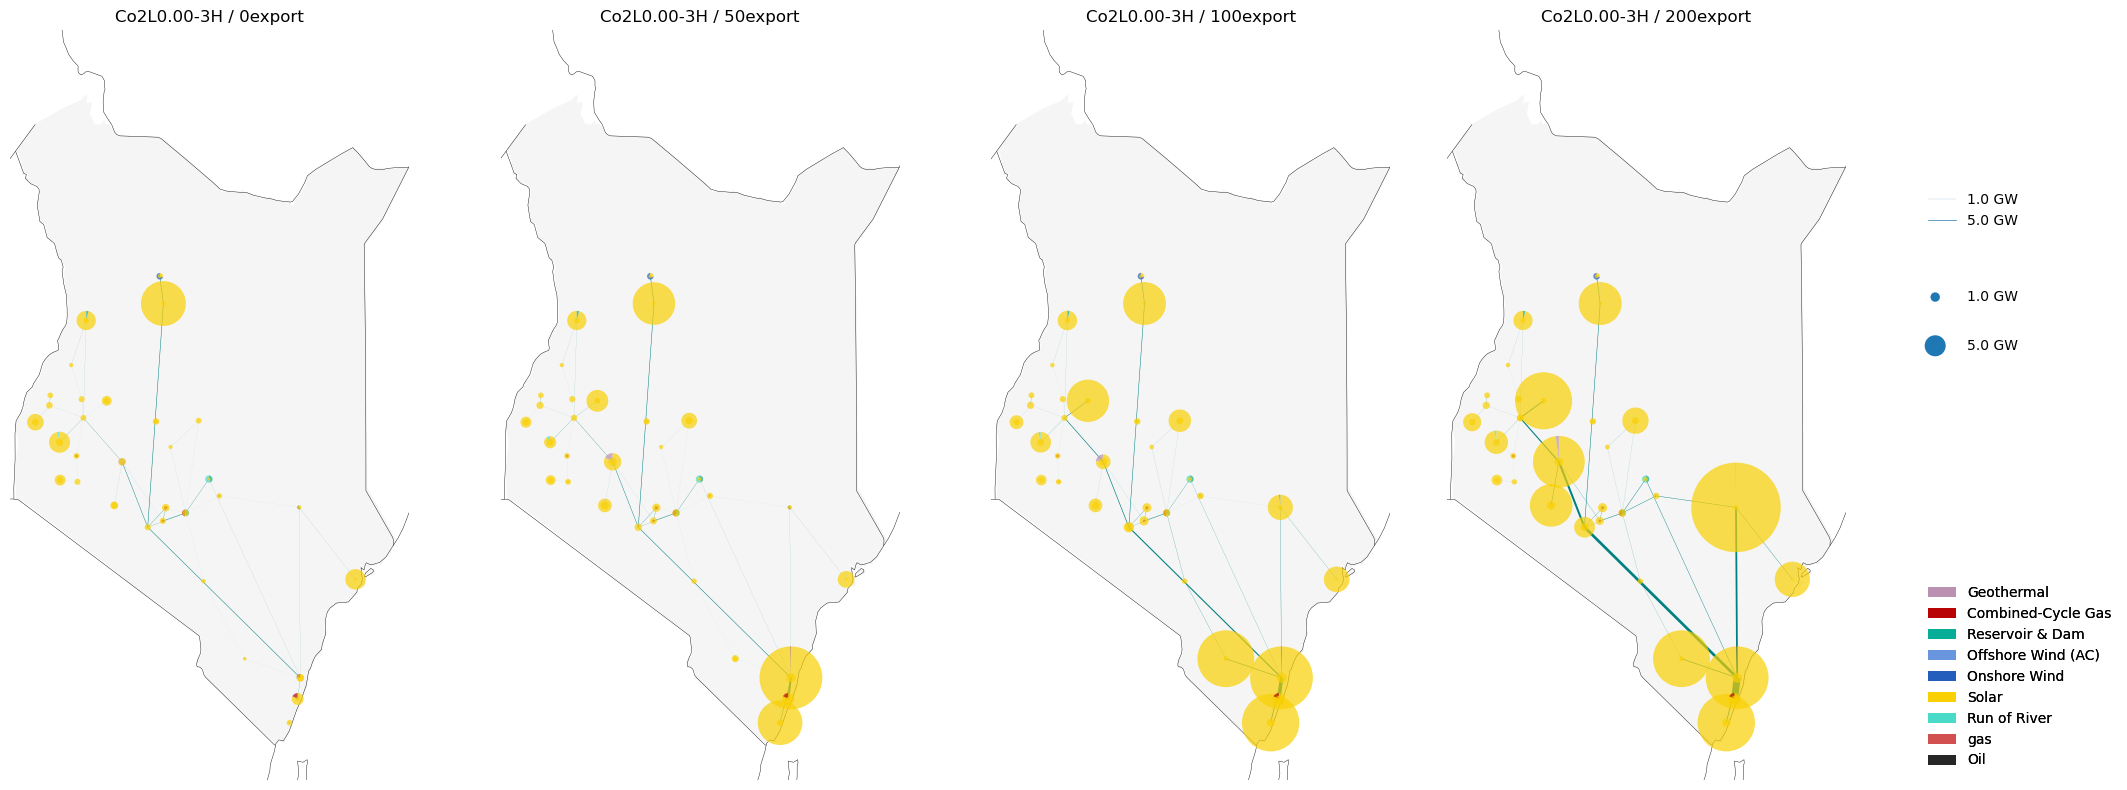

In [6]:
import warnings

warnings.simplefilter(action='ignore', category=UserWarning)

# --- Scale settings ---
bus_scale = 10e4 
line_scale = 10e3

# --- Legend settings ---
bus_sizes = [1000, 5000]  # in MW
line_sizes = [1000, 5000]  # in MW

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create figure and axes with extra axis for legend
fig, axes = plt.subplots(
    1, len(nc_files), figsize=(5 * len(nc_files) + 2, 8),
    subplot_kw={"projection": ccrs.EqualEarth()}
)

# If only one axis, make it iterable
if len(nc_files) == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Add extra axis for legend
divider = make_axes_locatable(axes[-1])
legend_ax = divider.append_axes("right", size="15%", pad=0.1, axes_class=plt.Axes)
legend_ax.axis("off")

# Prepare a list of (co2_policy, export_policy, n) for plotting order
plot_items = []
for co2_policy, exports_dict in networks.items():
    for export_policy, n in exports_dict.items():
        plot_items.append((co2_policy, export_policy, n))

for ax, (co2_policy, export_policy, n) in zip(axes, plot_items):
    # TODO: Ensure that every carrier has a color and a nice name in the config, then we can delete this code cell
    # --- Ensure all carriers have color and nice_name ---
    missing_carriers = [
        'lignite', 'coal', 'solar rooftop', 'oil', 'gas',
        'residential rural solar thermal',
        'residential urban decentral solar thermal',
        'services rural solar thermal',
        'services urban decentral solar thermal',
        'urban central solar thermal',
        'ccgt'
    ]

    carrier_color_mapping = {
        'lignite': 'coal',
        'solar rooftop': 'solar',
        'residential rural solar thermal': 'solar',
        'residential urban decentral solar thermal': 'solar',
        'services rural solar thermal': 'solar',
        'services urban decentral solar thermal': 'solar',
        'urban central solar thermal': 'solar',
        'ccgt': 'gas'
    }

    # Assign colors for missing carriers
    for c, ref in carrier_color_mapping.items():
        n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

    # Set nice_names
    n.carriers.loc['coal', 'nice_name'] = 'Coal'
    n.carriers.loc['oil', 'nice_name'] = 'Oil'
    n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

    for c, ref in carrier_color_mapping.items():
        if c not in ['ccgt']:  # ccgt already has its own name
            n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']
    
    # Ensure nice_name and color
    mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
    n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()
    mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
    n.carriers.loc[mask_color, "color"] = "gray"

    # Aggregate capacities
    gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
    sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
    buses = pd.concat([gen, sto])

    # Filter links
    link_bus0_base = n.links.bus0.str.split("_AC").str[0]
    link_bus1_base = n.links.bus1.str.split("_AC").str[0]
    valid_links = n.links[
        link_bus0_base.isin(gadm_shapes.index) &
        link_bus1_base.isin(gadm_shapes.index) &
        (n.links.p_nom_opt > 0)
    ]
    links_backup = n.links
    n.links = valid_links

    with plt.rc_context({"patch.linewidth": 0.}):
        n.plot(
            bus_sizes=buses / bus_scale,
            bus_alpha=0.7,
            line_widths=n.lines.s_nom_opt / line_scale,
            link_widths=n.links.p_nom_opt / line_scale,
            line_colors="teal",
            ax=ax,
            margin=0.2,
            color_geomap=None,
            # color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
        )

    regions_onshore.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0,
    )

    # Show gadm region borders
    # gadm_shapes.boundary.plot(
    #     ax=ax,
    #     edgecolor='darkgrey',
    #     aspect="equal",
    #     transform=ccrs.PlateCarree(),
    #     linewidth=1.2,
    #     zorder=3,
    #     alpha=0.9,
    #     label="Region Borders"
    # )

    # Zoom the map
    # Extend a bit into the north
    bounds = regions_onshore.total_bounds
    bounds[3] += (bounds[3] - bounds[1]) * 0.1
    # Extend into the south
    bounds[1] -= (bounds[3] - bounds[1]) * 0.05
    # country_coordinates = bounds[[0, 2, 1, 3]]
    ax.set_extent(bounds[[0, 2, 1, 3]])

    # Restore original links
    n.links = links_backup

    # Set title
    ax.set_title(f"{co2_policy} / {export_policy}")

# --- Add legends in the dedicated legend axis ---
# Circles legend (bus sizes)
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}
add_legend_circles(
    legend_ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
# Lines legend (line sizes)
add_legend_lines(
    legend_ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
# Carrier color legend
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0
    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)
add_legend_patches(
    legend_ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

warnings.simplefilter(action="default", category=UserWarning)
fig.tight_layout()

# Save figure without white borders
if save_figs:
    # Ensure the directory exists
    output_dir = f"pypsa-earth-docu/results/KE/graphics_general/"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}{overall_name}_all_networks.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()


<Axes: xlabel='carrier,bus_carrier'>

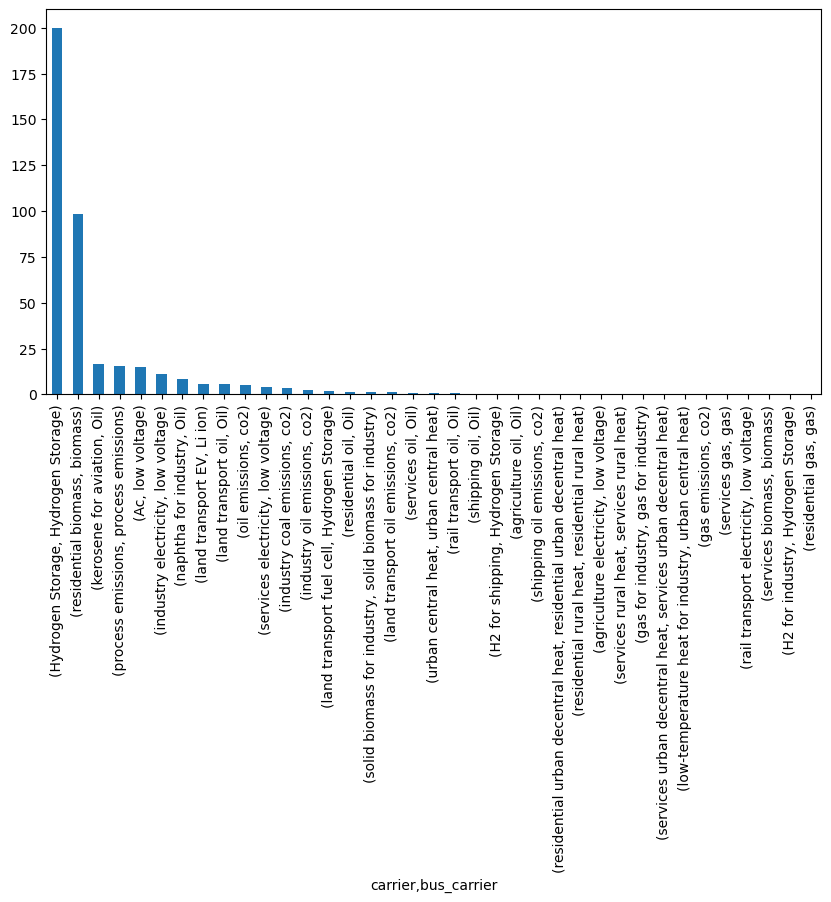

In [7]:
(n.statistics.energy_balance(comps="Load") / 1e6).abs().sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))

In [8]:
n.buses[n.buses.carrier == 'AC']

,v_nom,tag_substation,tag_area,lon,lat,country,carrier,x,y,control,generator,location,unit,type,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,sub_network
Bus,,,,,,,,,,,,,,,,,,
KE.10_1_AC,380.0,transmission,0.0,36.595000,-1.418500,KE,AC,36.595000,-1.418500,Slack,KE.10_1_AC onwind,KE.10_1_AC,MWh,,1.0,0.0,inf,
KE.11_1_AC,380.0,transmission,0.0,34.614450,0.407700,KE,AC,34.614450,0.407700,PQ,,KE.11_1_AC,MWh,,1.0,0.0,inf,
KE.12_1_AC,380.0,transmission,0.0,35.158200,-0.349950,KE,AC,35.158200,-0.349950,PQ,,KE.12_1_AC,MWh,,1.0,0.0,inf,
KE.13_1_AC,380.0,transmission,0.0,36.956120,-1.125940,KE,AC,36.956120,-1.125940,PQ,,KE.13_1_AC,MWh,,1.0,0.0,inf,
KE.14_1_AC,380.0,transmission,0.0,39.696814,-3.677029,KE,AC,39.696814,-3.677029,PQ,,KE.14_1_AC,MWh,,1.0,0.0,inf,
KE.16_1_AC,380.0,transmission,0.0,34.829700,-0.712600,KE,AC,34.829700,-0.712600,PQ,,KE.16_1_AC,MWh,,1.0,0.0,inf,
KE.17_1_AC,380.0,transmission,0.0,34.817700,-0.145433,KE,AC,34.817700,-0.145433,PQ,,KE.17_1_AC,MWh,,1.0,0.0,inf,
KE.18_1_AC,380.0,transmission,0.0,38.032800,-0.949200,KE,AC,38.032800,-0.949200,PQ,,KE.18_1_AC,MWh,,1.0,0.0,inf,
KE.19_1_AC,380.0,transmission,0.0,39.493850,-4.351150,KE,AC,39.493850,-4.351150,PQ,,KE.19_1_AC,MWh,,1.0,0.0,inf,
